# Boltz-1 and Boltz-2: success, similarity and local training-set density

## Objective

This notebook applies the density-analysis logic used for the Runs N' Poses data to the 100 simulated complexes. Similarity is evaluated separately against the Boltz-1 and Boltz-2 training sets.

For every query, model and similarity metric, **neighbour density** is the number of training systems whose similarity is at or above the metric-specific threshold selected in `RUNSNPOSES_analysis_PART_2.ipynb`. Positive densities are split at the model- and metric-specific median into low- and high-density groups. Queries with zero qualifying neighbours remain a separate group.

The primary success endpoint is the fraction of the five predicted poses that satisfy the success criterion (`successful_pose_count / 5`). Line plots show mean success across model-specific similarity quantiles; violin plots show the underlying query-level distributions. Set `SUCCESS_MEASURE = "top1_success"` to repeat the analysis with binary top-ranked success.


In [ ]:
from pathlib import Path
import re
import warnings
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)


## Input files

The notebook reads external data from the directory specified by the
`BOLTZ_BENCHMARK_DATA` environment variable. The following directory
structure is expected:

```text
BOLTZ_BENCHMARK_DATA/
├── boltz_results/
│   └── *_model_summary.csv
├── similarity_results/
│   ├── boltz1/
│   │   └── final_reports/
│   └── boltz2/
│       └── final_reports/
└── analysis_outputs/
    └── threshold_density_analysis/
        └── selected_similarity_thresholds.csv
```

In [ ]:
# Directory containing the external benchmark and similarity data.
base_path_value = os.environ.get("BOLTZ_BENCHMARK_DATA")

if not base_path_value:
    raise RuntimeError(
        "BOLTZ_BENCHMARK_DATA is not defined. "
        "Set it to the directory containing the benchmark data."
    )

BASE_PATH = Path(base_path_value).expanduser().resolve()

BOLTZ_RESULTS_DIR = BASE_PATH / "boltz_results"
SIMILARITY_RESULTS_DIR = BASE_PATH / "similarity_results"

BOLTZ1_REPORTS = SIMILARITY_RESULTS_DIR / "boltz1"
BOLTZ2_REPORTS = SIMILARITY_RESULTS_DIR / "boltz2"

THRESHOLD_PATH = (
    BASE_PATH
    / "analysis_outputs"
    / "threshold_density_analysis"
    / "selected_similarity_thresholds.csv"
)

OUTPUT_DIR = (
    BASE_PATH
    / "analysis_outputs"
    / "boltz_success_similarity_density"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", BASE_PATH)
print("Boltz results:", BOLTZ_RESULTS_DIR)
print("Similarity results:", SIMILARITY_RESULTS_DIR)
print("Threshold file:", THRESHOLD_PATH)
print("Output directory:", OUTPUT_DIR)

In [ ]:
SUCCESS_MEASURE = "pose_success_fraction"  # or "top1_success", "best_of_5_success"
N_PREDICTED_POSES = 5
N_QUANTILES = 5
STRICT_COVERAGE = True

METRICS = {
    "protein_fident_max": "Protein sequence",
    "protein_lddt_max": "Protein structure",
    "pocket_qcov": "Pocket",
    "pli_qcov": "Interaction",
    "sucos_shape": "Ligand pose",
    "morgan_tanimoto": "Ligand chemistry",
}

ALL_PDB_IDS = "9RV0 9TFA 9Y56 10QV 9RMF 9RQV 9VO8 9VQ5 21LN 13LW 11UE 11UC 11LJ 10PJ 24UH 29MO 7EDQ 9YMO 9I9E 9RC9 9TK2 9TKU 9LOK 9VCZ 9VBQ 9T43 9RFL 9P09 9ZO9 9HZ3 31WA 31WB 32PP 35WF 35WG 9PSQ 9YBT 31HP 32QL 32QM 9RZO 9RZP 9VZG 9HVS 9HVT 9TF9 9TFB 9Y57 9Y5A 9HM1 9RQW 9RQX 9PPL 24WC 13LX 9SUV 9VZS 9VZT 9ZME 9SZN 9ZMG 9T9E 9T9F 9O7R 9QZR 9O73 9OLE 9ORM 9UAU 9Y8K 9UGF 9Y8L 9ZXM 9ZXN 9MAW 9QDY 9Z1L 10KZ 22MJ 9Q8D 9Z2S 9R1C 9LZX 9N3L 9I9G 9R6I 9T08 9T0D 9NGP 8ZNN 9UZT 9I3Y 9S1U 9SI4 9NWX 9HTR 9KLY 9ND3 9X53 9OGW".lower().split()

NOT_CALCULABLE = {
    "7edq", "9lok", "9rqv", "9maw", "9o73", "9qzr", "9ybt"
}
NO_TARGETS = {"9lzx", "9t9e", "9t9f"}
EXPECTED_REPORT_IDS = sorted(set(ALL_PDB_IDS) - NOT_CALCULABLE - NO_TARGETS)

print("Simulated complexes:", len(ALL_PDB_IDS))
print("Expected similarity reports per model:", len(EXPECTED_REPORT_IDS))
print("Not calculable:", sorted(NOT_CALCULABLE))
print("No targets:", sorted(NO_TARGETS))


Simulated complexes: 100
Expected similarity reports per model: 90
Not calculable: ['7edq', '9lok', '9maw', '9o73', '9qzr', '9rqv', '9ybt']
No targets: ['9lzx', '9t9e', '9t9f']


## Load and audit prediction success

The model summaries contain one row per complex and model. `pose_success_fraction` is used by default because it produces a query-level distribution analogous to the continuous mean-success endpoint used in the Runs N' Poses density analysis.


In [3]:
def normalise_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")
    return (
        series.astype(str).str.strip().str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .astype("boolean")
    )


summary_paths = sorted(BOLTZ_RESULTS_DIR.rglob("*_model_summary.csv"))
if not summary_paths:
    raise FileNotFoundError(
        f"No *_model_summary.csv files found below {BOLTZ_RESULTS_DIR}"
    )

success_frames = []
for path in summary_paths:
    frame = pd.read_csv(path)
    if "pdb_id" not in frame:
        frame["pdb_id"] = path.name.split("_model_summary.csv")[0]
    frame["source_file"] = str(path)
    success_frames.append(frame)

success_df = pd.concat(success_frames, ignore_index=True)
success_df["pdb_id"] = success_df["pdb_id"].astype(str).str.lower().str.strip()
success_df["model"] = success_df["model"].astype(str).str.lower().map({
    "boltz1": "Boltz-1", "boltz-1": "Boltz-1",
    "boltz2": "Boltz-2", "boltz-2": "Boltz-2",
})

for column in ["top1_success", "best_of_5_success"]:
    if column in success_df:
        success_df[column] = normalise_bool(success_df[column])

success_df["successful_pose_count"] = pd.to_numeric(
    success_df["successful_pose_count"], errors="coerce"
)
success_df["pose_success_fraction"] = (
    success_df["successful_pose_count"] / N_PREDICTED_POSES
)
success_df = success_df.drop_duplicates(["pdb_id", "model"], keep="last")

if SUCCESS_MEASURE not in success_df:
    raise KeyError(
        f"SUCCESS_MEASURE={SUCCESS_MEASURE!r} is unavailable. "
        f"Columns: {success_df.columns.tolist()}"
    )
success_df["success"] = pd.to_numeric(success_df[SUCCESS_MEASURE], errors="coerce")

expected_success_index = pd.MultiIndex.from_product(
    [ALL_PDB_IDS, ["Boltz-1", "Boltz-2"]], names=["pdb_id", "model"]
)
observed_success_index = pd.MultiIndex.from_frame(success_df[["pdb_id", "model"]])
missing_success = expected_success_index.difference(observed_success_index)

print("Summary files:", len(summary_paths))
print("Complex-model rows:", len(success_df))
print("Missing complex-model rows:", len(missing_success))
if len(missing_success):
    display(pd.DataFrame(missing_success.tolist(), columns=["pdb_id", "model"]))
    if STRICT_COVERAGE:
        raise RuntimeError(
            "Prediction summaries are incomplete. Copy all 100 model-summary "
            "CSVs before producing final figures."
        )


Summary files: 148
Complex-model rows: 200
Missing complex-model rows: 0


## Load pairwise similarities and audit report coverage

Each `pdb_target_scores.parquet` retains the individual query-to-training-system similarities needed to count neighbours. Maxima alone are insufficient for density analysis.


In [4]:
def load_similarity_pairs(report_root, model, training_set):
    paths = sorted(report_root.rglob("pdb_target_scores.parquet"))
    frames = []
    seen = set()

    for path in paths:
        pdb_id = path.parent.name.lower()
        key = (pdb_id, model)
        if key in seen:
            warnings.warn(f"Duplicate similarity report ignored: {path}")
            continue
        seen.add(key)

        frame = pd.read_parquet(path)
        frame["pdb_id"] = pdb_id
        frame["model"] = model
        frame["training_set"] = training_set
        frame["source_file"] = str(path)
        frames.append(frame)

    if not frames:
        raise FileNotFoundError(
            f"No pdb_target_scores.parquet files found below {report_root}"
        )
    return pd.concat(frames, ignore_index=True), paths


b1_pairs, b1_paths = load_similarity_pairs(
    BOLTZ1_REPORTS, "Boltz-1", "release < 2021-09-30"
)
b2_pairs, b2_paths = load_similarity_pairs(
    BOLTZ2_REPORTS, "Boltz-2", "release < 2023-06-01"
)
similarity_pairs_df = pd.concat([b1_pairs, b2_pairs], ignore_index=True)

for column in METRICS:
    similarity_pairs_df[column] = pd.to_numeric(
        similarity_pairs_df.get(column), errors="coerce"
    )
    maximum = similarity_pairs_df[column].max(skipna=True)
    if pd.notna(maximum) and maximum <= 1:
        similarity_pairs_df[column] *= 100

coverage_rows = []
for model, frame in similarity_pairs_df.groupby("model", observed=True):
    observed = set(frame["pdb_id"].unique())
    missing = sorted(set(EXPECTED_REPORT_IDS) - observed)
    unexpected = sorted(observed - set(EXPECTED_REPORT_IDS))
    coverage_rows.append({
        "model": model,
        "expected_reports": len(EXPECTED_REPORT_IDS),
        "observed_reports": len(observed & set(EXPECTED_REPORT_IDS)),
        "missing_reports": len(missing),
        "unexpected_reports": len(unexpected),
        "missing_pdb_ids": ", ".join(missing),
    })
coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

if STRICT_COVERAGE and coverage_df["missing_reports"].gt(0).any():
    raise RuntimeError(
        "Similarity reports are incomplete. Copy all 90 report directories "
        "for both training sets before producing final figures."
    )

print("Pairwise similarity rows:", len(similarity_pairs_df))


,model,expected_reports,observed_reports,missing_reports,unexpected_reports,missing_pdb_ids
0,Boltz-1,90,90,0,0,
1,Boltz-2,90,90,0,0,


Pairwise similarity rows: 516782


## Reuse the Runs N' Poses thresholds

Thresholds are imported from `selected_similarity_thresholds.csv`, created by `RUNSNPOSES_analysis_PART_2.ipynb`. They are fixed before analysing the 100 simulated complexes.


In [5]:
if not THRESHOLD_PATH.exists():
    raise FileNotFoundError(
        f"Selected-threshold table not found: {THRESHOLD_PATH}"
    )

selected_thresholds_df = pd.read_csv(THRESHOLD_PATH)
threshold_by_column = dict(zip(
    selected_thresholds_df["similarity_column"],
    selected_thresholds_df["threshold"],
))

missing_thresholds = sorted(set(METRICS) - set(threshold_by_column))
if missing_thresholds:
    raise KeyError(f"Missing thresholds for: {missing_thresholds}")

threshold_table = pd.DataFrame({
    "metric_column": list(METRICS),
    "metric": [METRICS[column] for column in METRICS],
    "threshold": [threshold_by_column[column] for column in METRICS],
})
display(threshold_table)


,metric_column,metric,threshold
0,protein_fident_max,Protein sequence,50
1,protein_lddt_max,Protein structure,70
2,pocket_qcov,Pocket,70
3,pli_qcov,Interaction,50
4,sucos_shape,Ligand pose,50
5,morgan_tanimoto,Ligand chemistry,50


## Calculate neighbour density and model-specific similarity quantiles

Density is counted independently for Boltz-1 and Boltz-2 because their training sets differ. Positive densities are divided at the median within each model and metric. Similarity quantiles are likewise model-specific, so Q1–Q5 represent relative exposure within the corresponding training set rather than identical numerical ranges.


In [6]:
def build_density_table(similarity_pairs, success, metrics, thresholds):
    tables = []
    definitions = []

    for model in ["Boltz-1", "Boltz-2"]:
        model_pairs = similarity_pairs.loc[similarity_pairs["model"].eq(model)]
        model_success = success.loc[
            success["model"].eq(model), ["pdb_id", "model", "success"]
        ]

        for metric_column, metric_name in metrics.items():
            threshold = float(thresholds[metric_column])
            metric_pairs = model_pairs[["pdb_id", metric_column]].dropna()

            features = (
                metric_pairs.groupby("pdb_id")[metric_column]
                .agg(
                    best_similarity="max",
                    neighbour_density=lambda values: values.ge(threshold).sum(),
                    mean_neighbour_similarity=lambda values: (
                        values.loc[values.ge(threshold)].mean()
                    ),
                )
                .reset_index()
            )
            features["neighbour_density"] = features["neighbour_density"].astype(int)
            features["visualisation_similarity"] = features[
                "mean_neighbour_similarity"
            ].fillna(features["best_similarity"])

            query_df = model_success.merge(
                features, on="pdb_id", how="inner", validate="one_to_one"
            )
            positive = query_df.loc[
                query_df["neighbour_density"].gt(0), "neighbour_density"
            ]
            if positive.empty:
                warnings.warn(f"No positive-density queries for {model}, {metric_name}")
                low_maximum = 0
                high_minimum = 1
                maximum = 0
            else:
                low_maximum = int(np.floor(positive.median()))
                high_minimum = low_maximum + 1
                maximum = int(positive.max())

            query_df["density_group"] = np.select(
                [
                    query_df["neighbour_density"].eq(0),
                    query_df["neighbour_density"].le(low_maximum),
                ],
                ["No neighbours", "Low density"],
                default="High density",
            )
            query_df["metric"] = metric_name
            query_df["metric_column"] = metric_column
            query_df["threshold"] = threshold
            query_df["model"] = model
            query_df["success_percent"] = 100 * query_df["success"]
            tables.append(query_df)

            for group, minimum, maximum_group in [
                ("No neighbours", 0, 0),
                ("Low density", 1, low_maximum),
                ("High density", high_minimum, maximum),
            ]:
                definitions.append({
                    "model": model,
                    "metric": metric_name,
                    "threshold": threshold,
                    "density_group": group,
                    "minimum_density": minimum,
                    "maximum_density": maximum_group,
                    "n_queries": int(query_df["density_group"].eq(group).sum()),
                })

    return pd.concat(tables, ignore_index=True), pd.DataFrame(definitions)


density_query_df, density_definition_df = build_density_table(
    similarity_pairs_df,
    success_df,
    METRICS,
    threshold_by_column,
)

density_query_df["similarity_quantile"] = pd.NA
density_query_df["similarity_quantile_label"] = pd.NA
quantile_boundaries = []

for (model, metric), index in density_query_df.groupby(
    ["model", "metric"], observed=True
).groups.items():
    valid = density_query_df.loc[index, "visualisation_similarity"].dropna()
    n_bins = min(N_QUANTILES, len(valid))
    if n_bins == 0:
        continue
    ranks = valid.rank(method="first")
    labels = [f"Q{i}" for i in range(1, n_bins + 1)]
    assigned = pd.qcut(ranks, q=n_bins, labels=labels).astype(str)
    density_query_df.loc[valid.index, "similarity_quantile"] = assigned

    for label in labels:
        label_index = assigned.index[assigned.eq(label)]
        values = density_query_df.loc[label_index, "visualisation_similarity"]
        lower, upper = values.min(), values.max()
        display_label = f"{label}\n{lower:.1f}–{upper:.1f}"
        density_query_df.loc[label_index, "similarity_quantile_label"] = display_label
        quantile_boundaries.append({
            "model": model,
            "metric": metric,
            "quantile": label,
            "minimum_similarity": lower,
            "maximum_similarity": upper,
            "n_queries": len(label_index),
        })

quantile_boundaries_df = pd.DataFrame(quantile_boundaries)
display(density_definition_df)
display(quantile_boundaries_df)


,model,metric,threshold,density_group,minimum_density,maximum_density,n_queries
0,Boltz-1,Protein sequence,50.0,No neighbours,0,0,9
1,Boltz-1,Protein sequence,50.0,Low density,1,62,42
2,Boltz-1,Protein sequence,50.0,High density,63,2359,39
3,Boltz-1,Protein structure,70.0,No neighbours,0,0,7
4,Boltz-1,Protein structure,70.0,Low density,1,268,42
5,Boltz-1,Protein structure,70.0,High density,269,2641,41
6,Boltz-1,Pocket,70.0,No neighbours,0,0,9
7,Boltz-1,Pocket,70.0,Low density,1,235,39
8,Boltz-1,Pocket,70.0,High density,236,4516,39
9,Boltz-1,Interaction,50.0,No neighbours,0,0,13


,model,metric,quantile,minimum_similarity,maximum_similarity,n_queries
0,Boltz-1,Interaction,Q1,0.000000,50.000000,18
1,Boltz-1,Interaction,Q2,50.000000,52.833333,17
2,Boltz-1,Interaction,Q3,53.000000,56.579112,17
3,Boltz-1,Interaction,Q4,56.621212,60.000000,17
4,Boltz-1,Interaction,Q5,60.327869,73.925926,17
5,Boltz-1,Ligand chemistry,Q1,6.779661,19.230769,18
6,Boltz-1,Ligand chemistry,Q2,20.000000,27.551020,18
7,Boltz-1,Ligand chemistry,Q3,27.722772,34.313725,18
8,Boltz-1,Ligand chemistry,Q4,35.365854,50.000000,18
9,Boltz-1,Ligand chemistry,Q5,50.000000,93.711368,18


## Direct Boltz-1 versus Boltz-2 comparison

These figures omit the high/low-density stratification. They include only queries with at least one training neighbour at or above the fixed metric threshold and compare Boltz-1 and Boltz-2 in the same axes. Quantiles remain model-specific because the two models have different training sets.

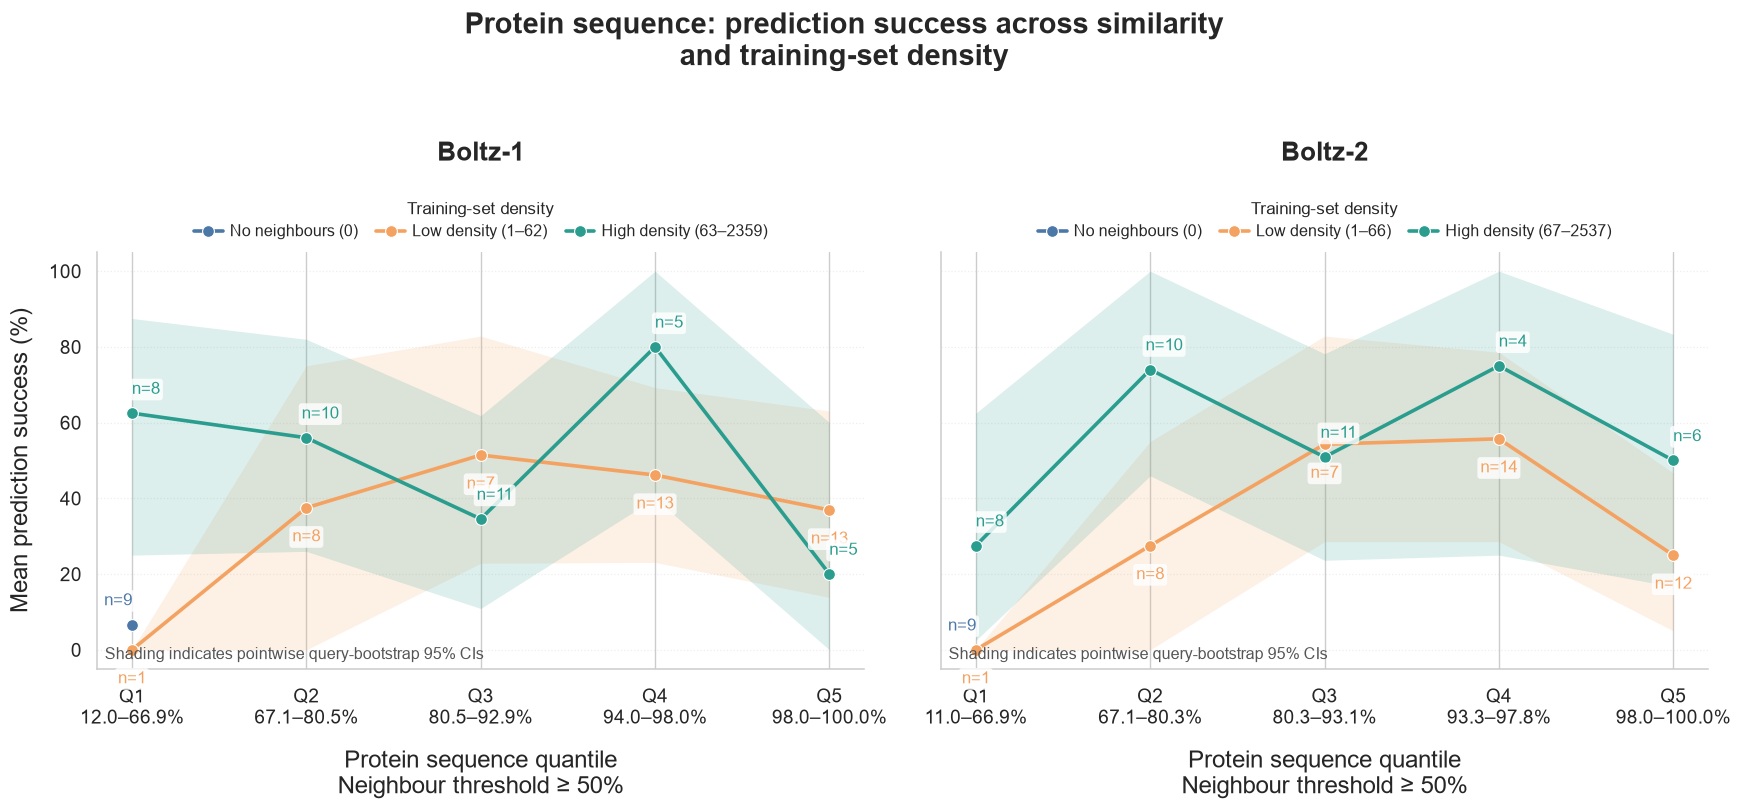

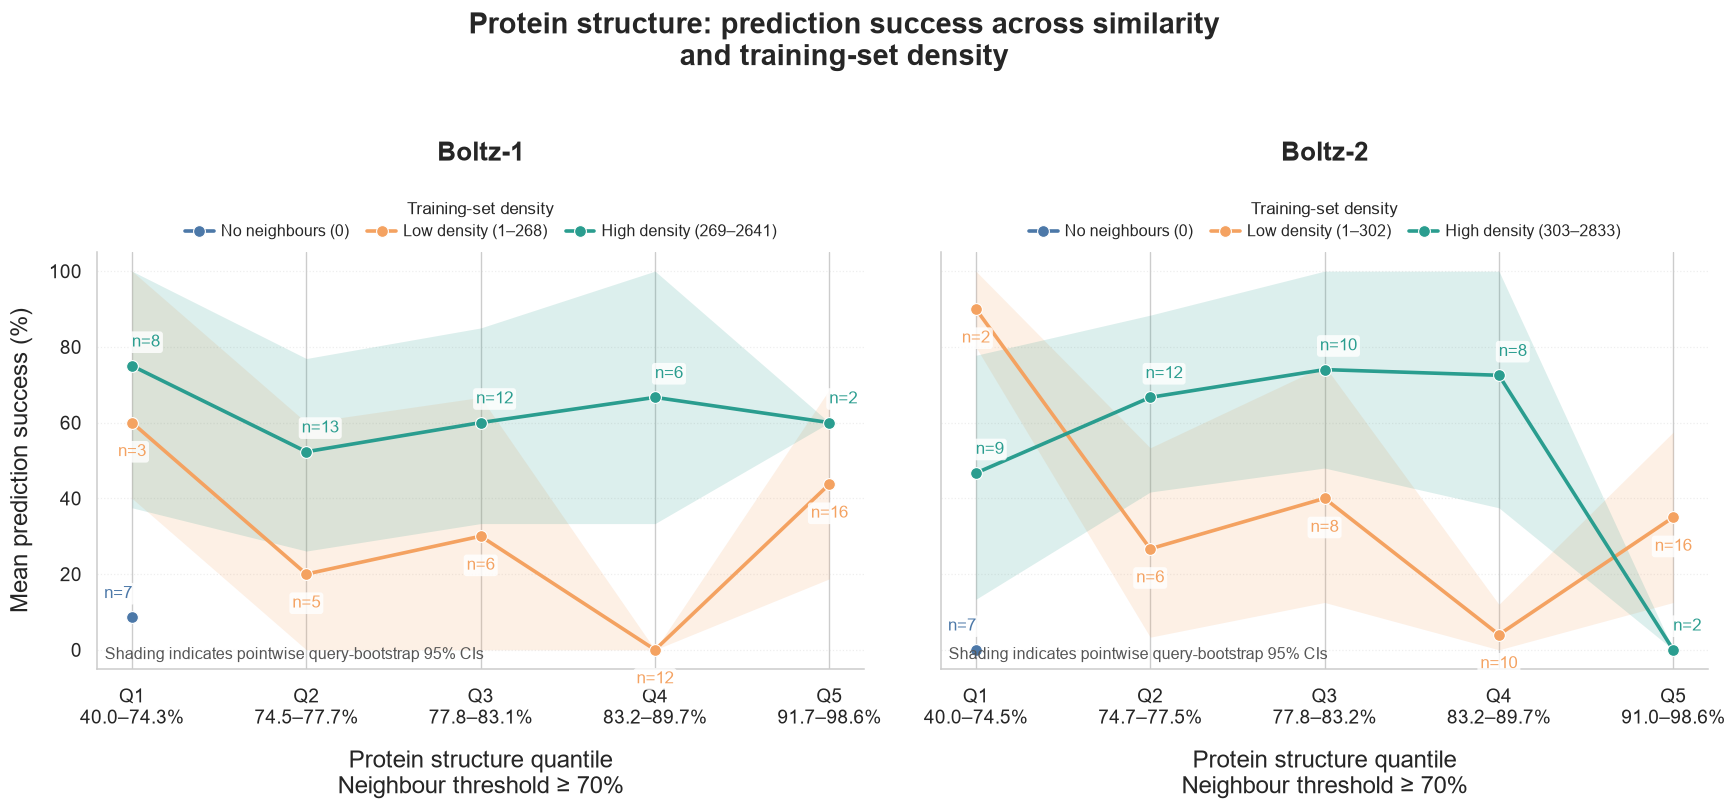

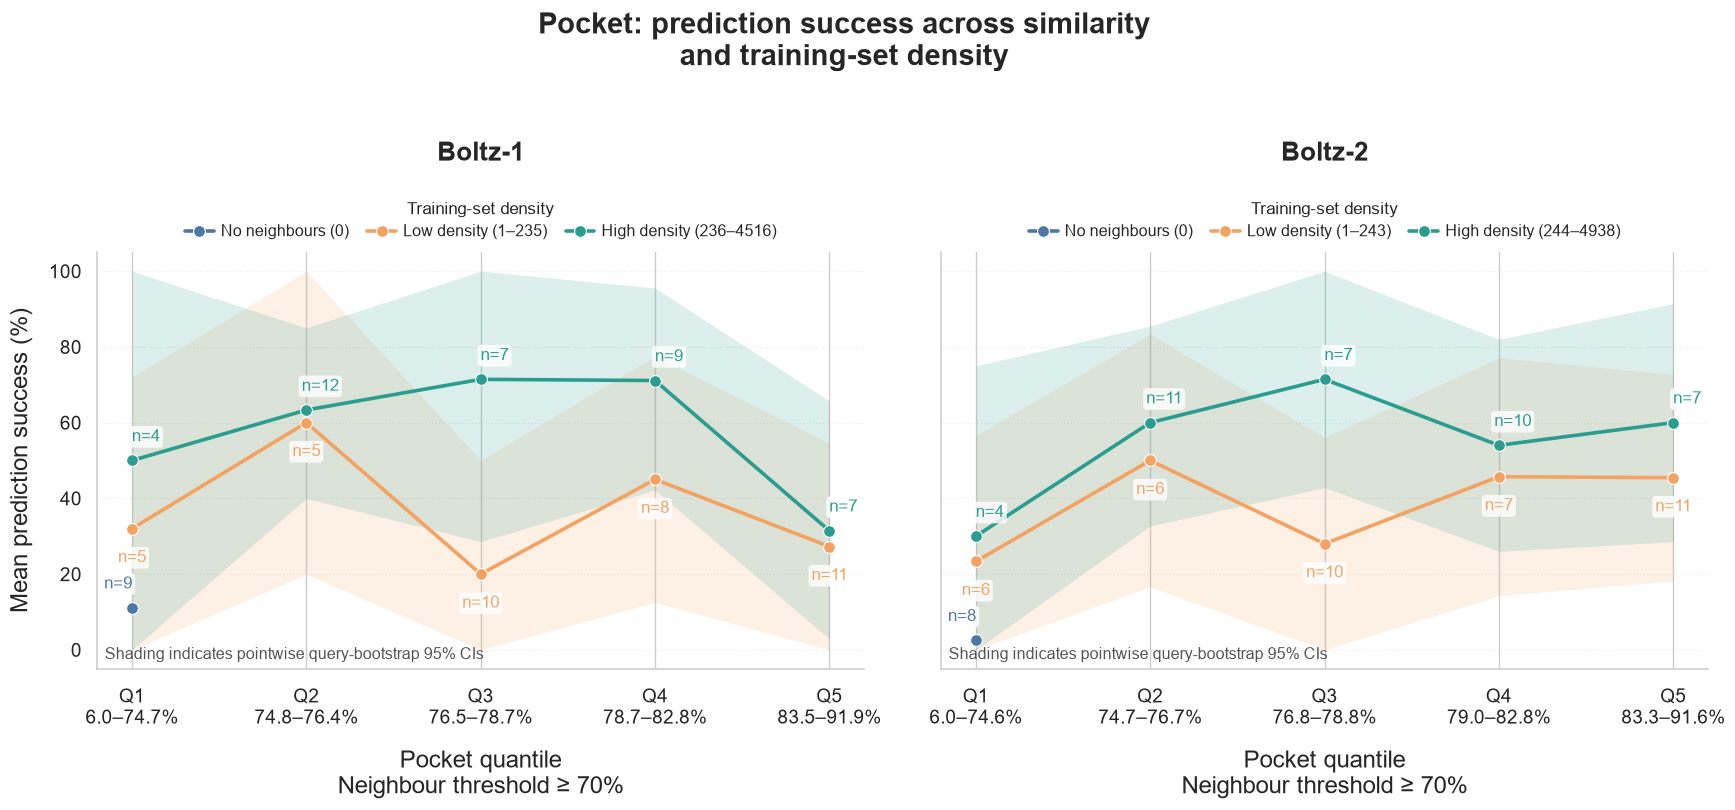

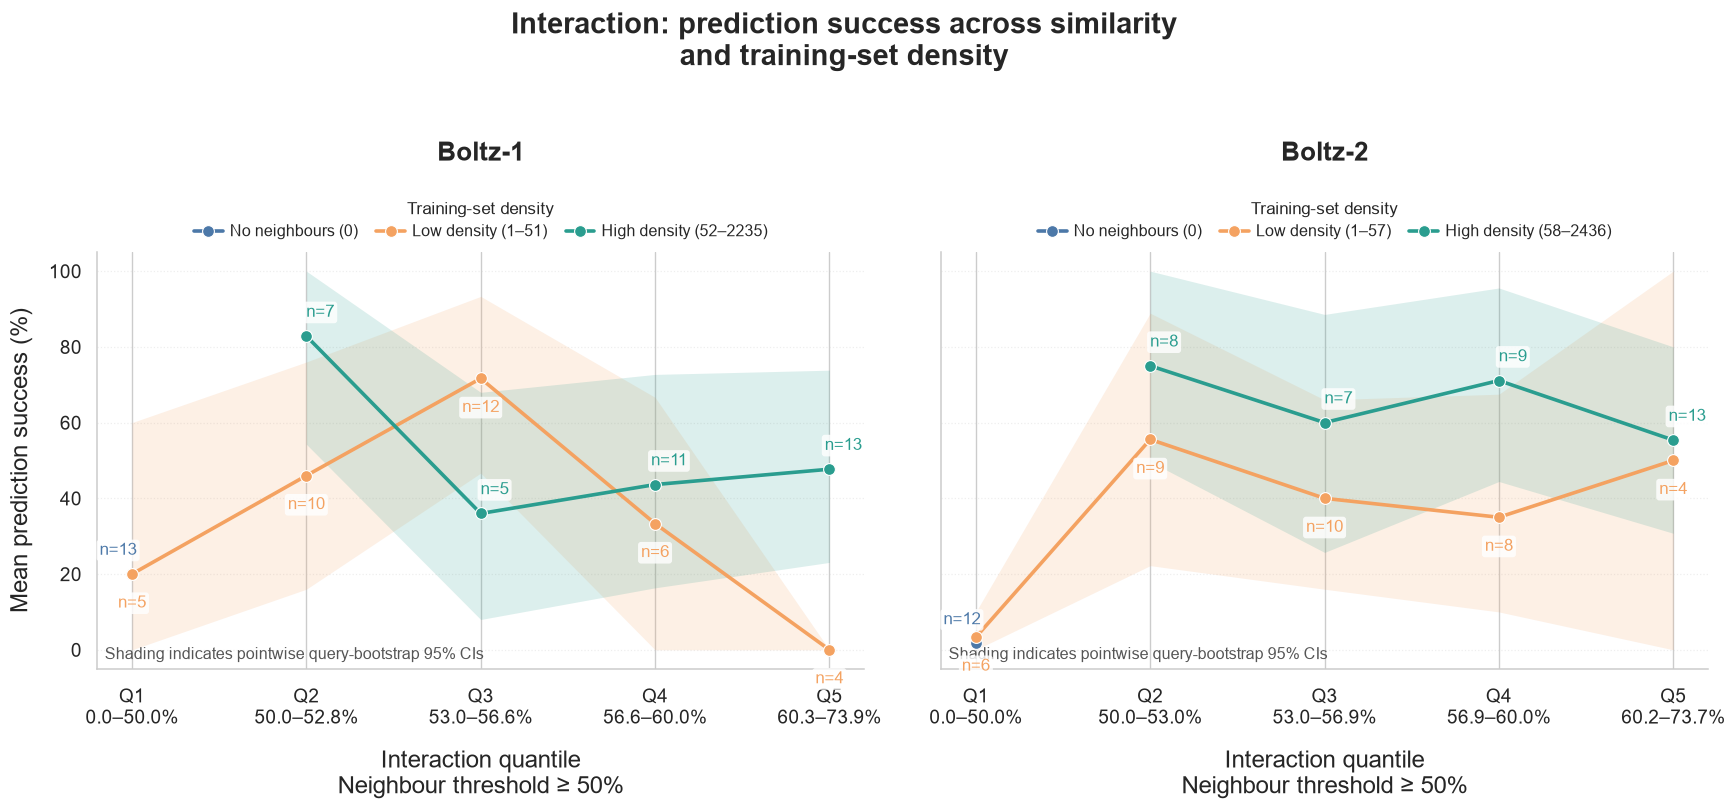

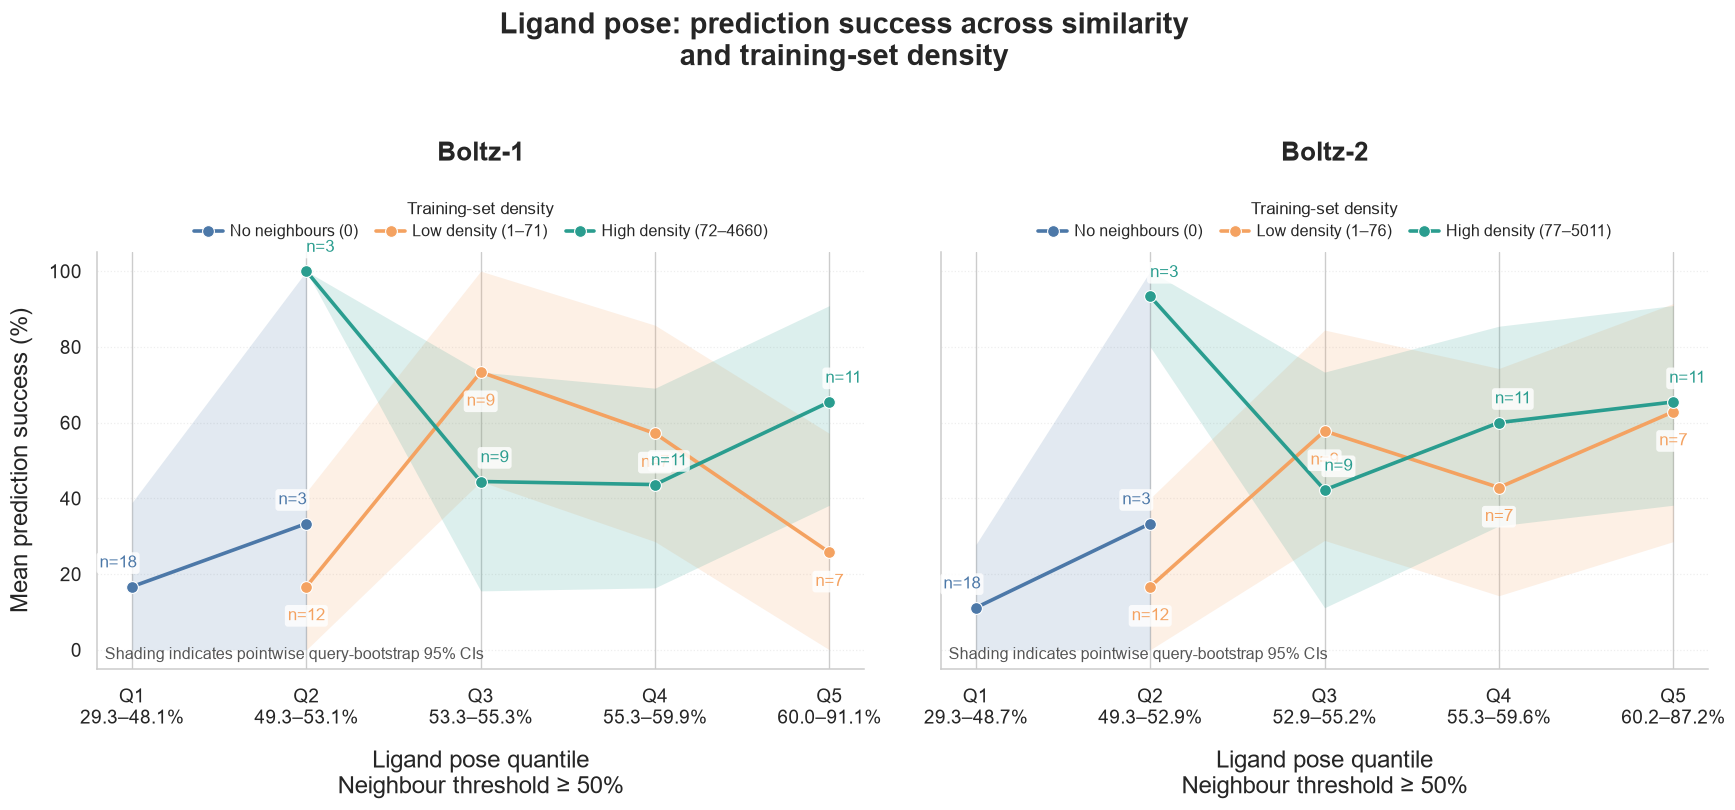

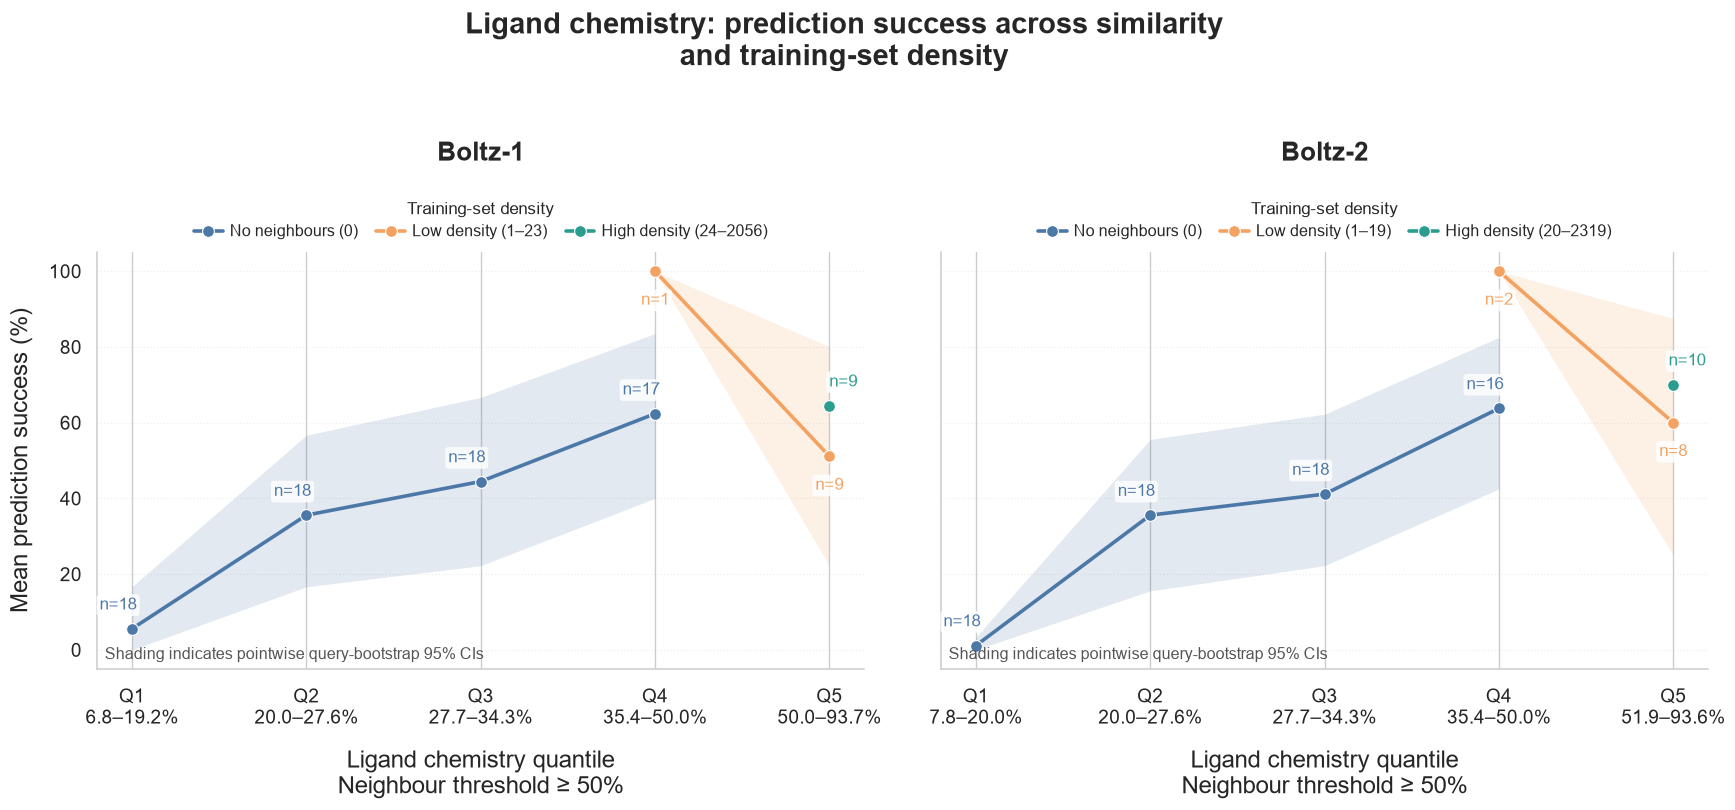

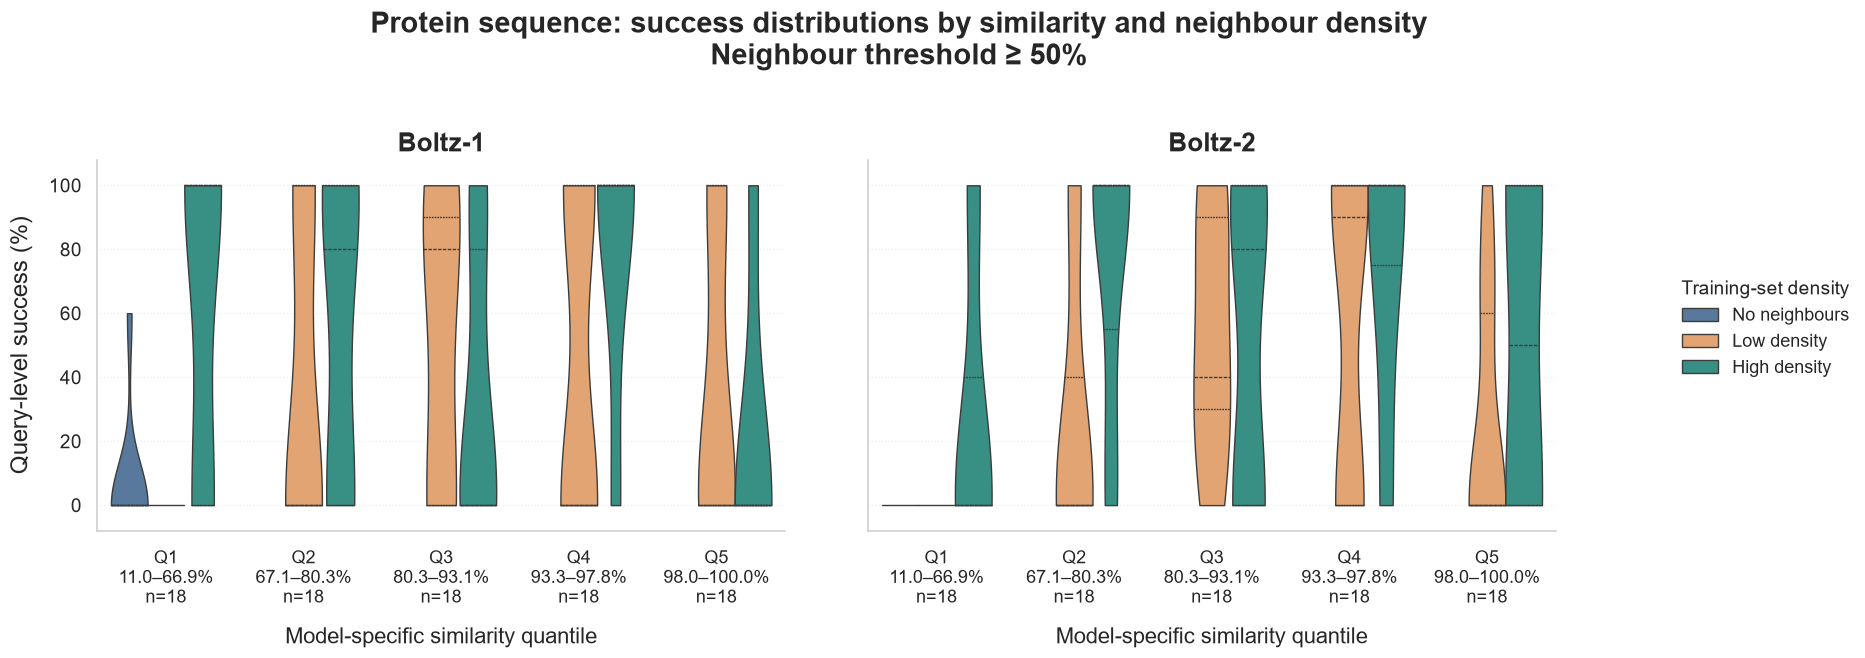

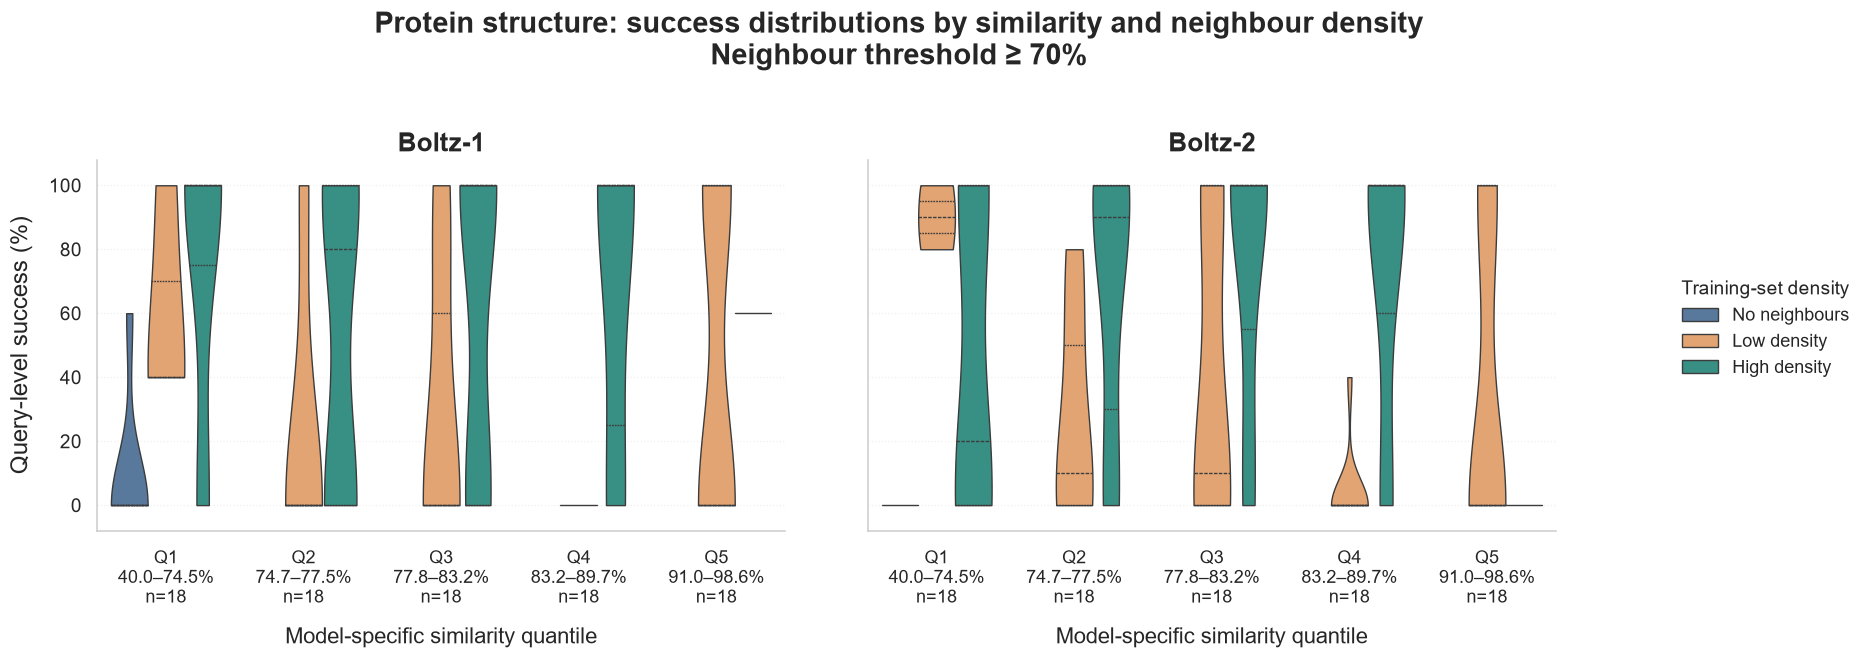

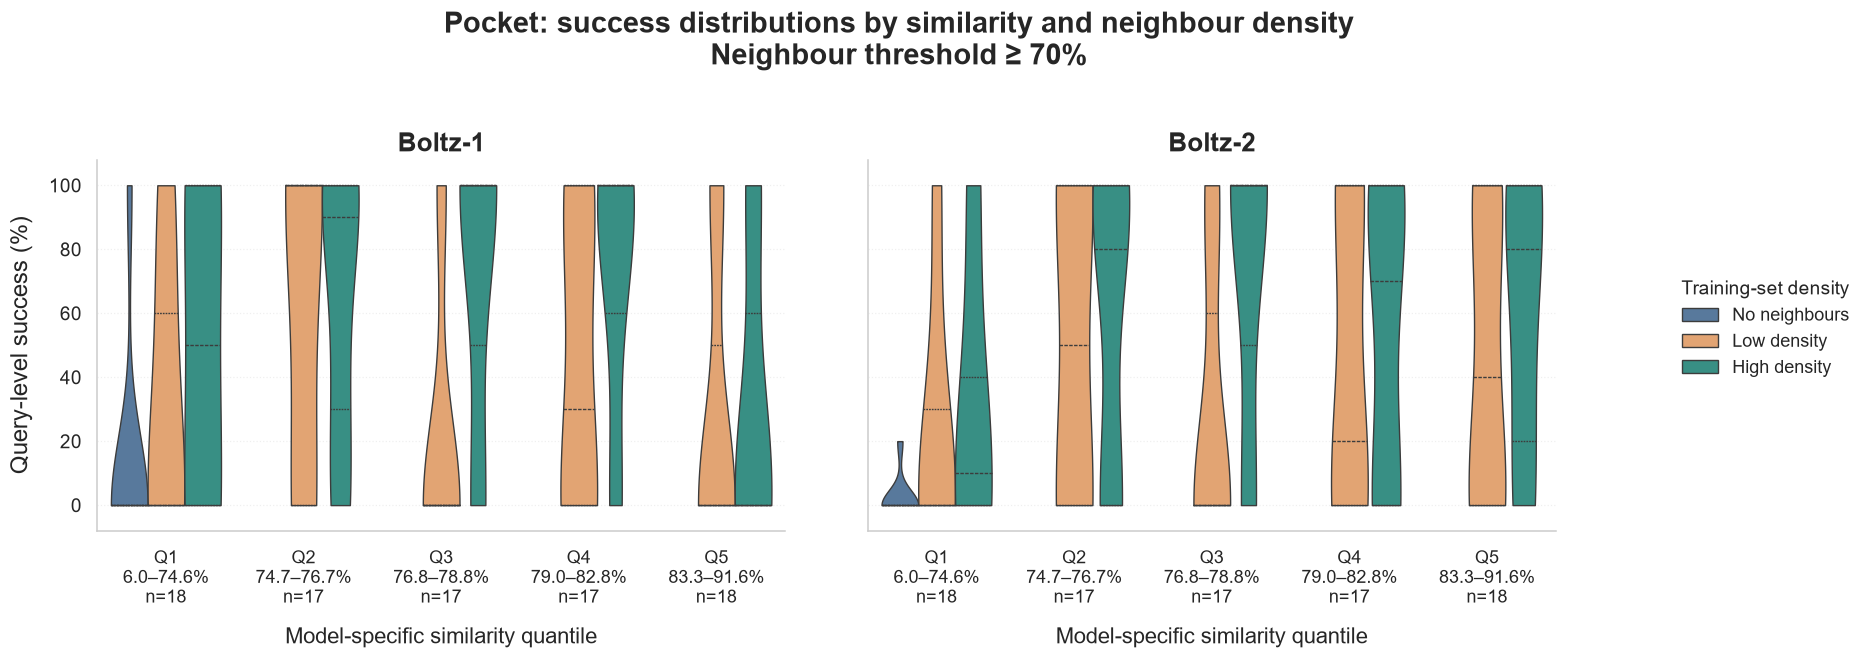

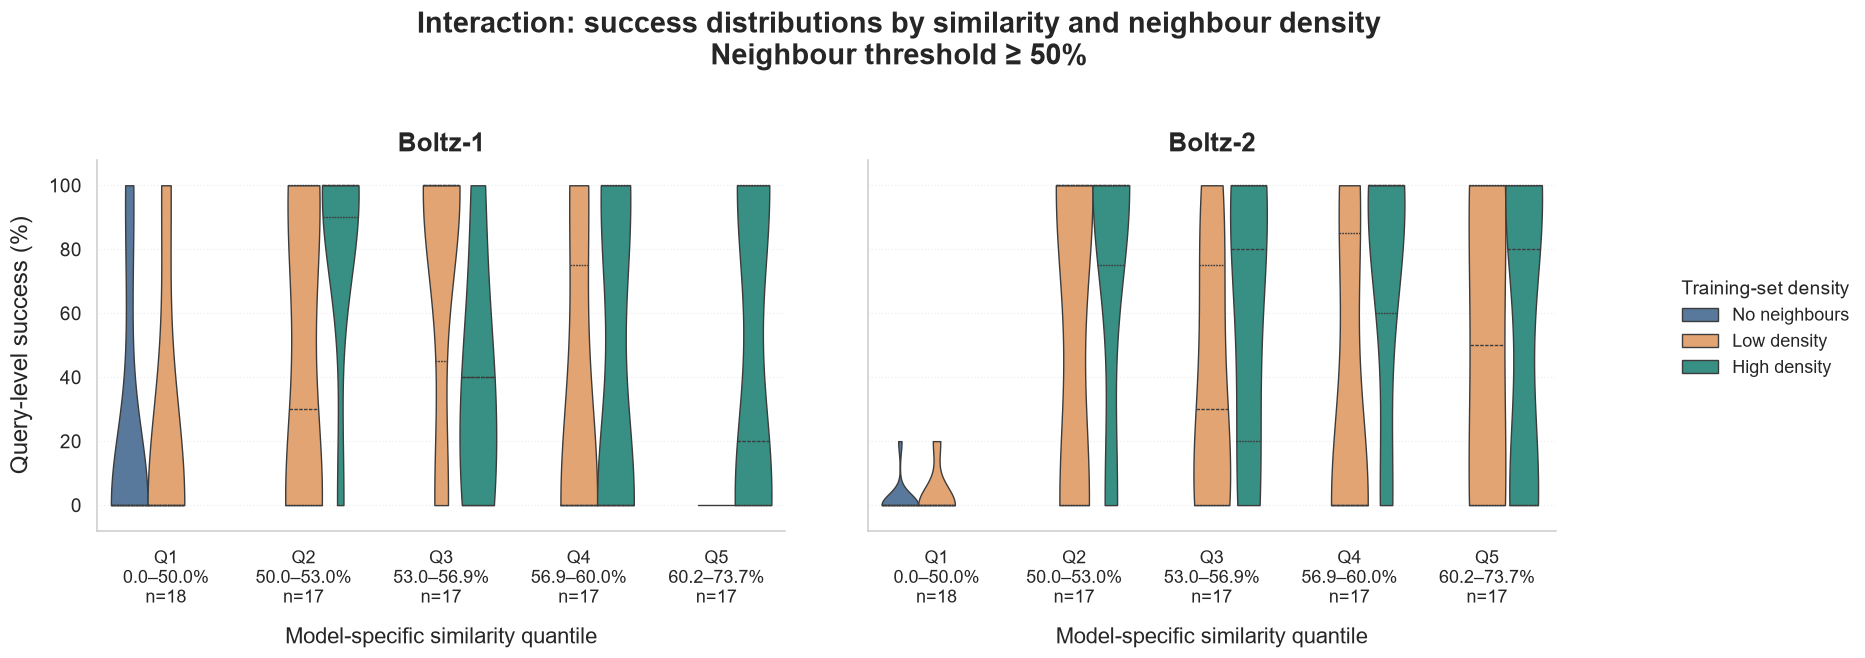

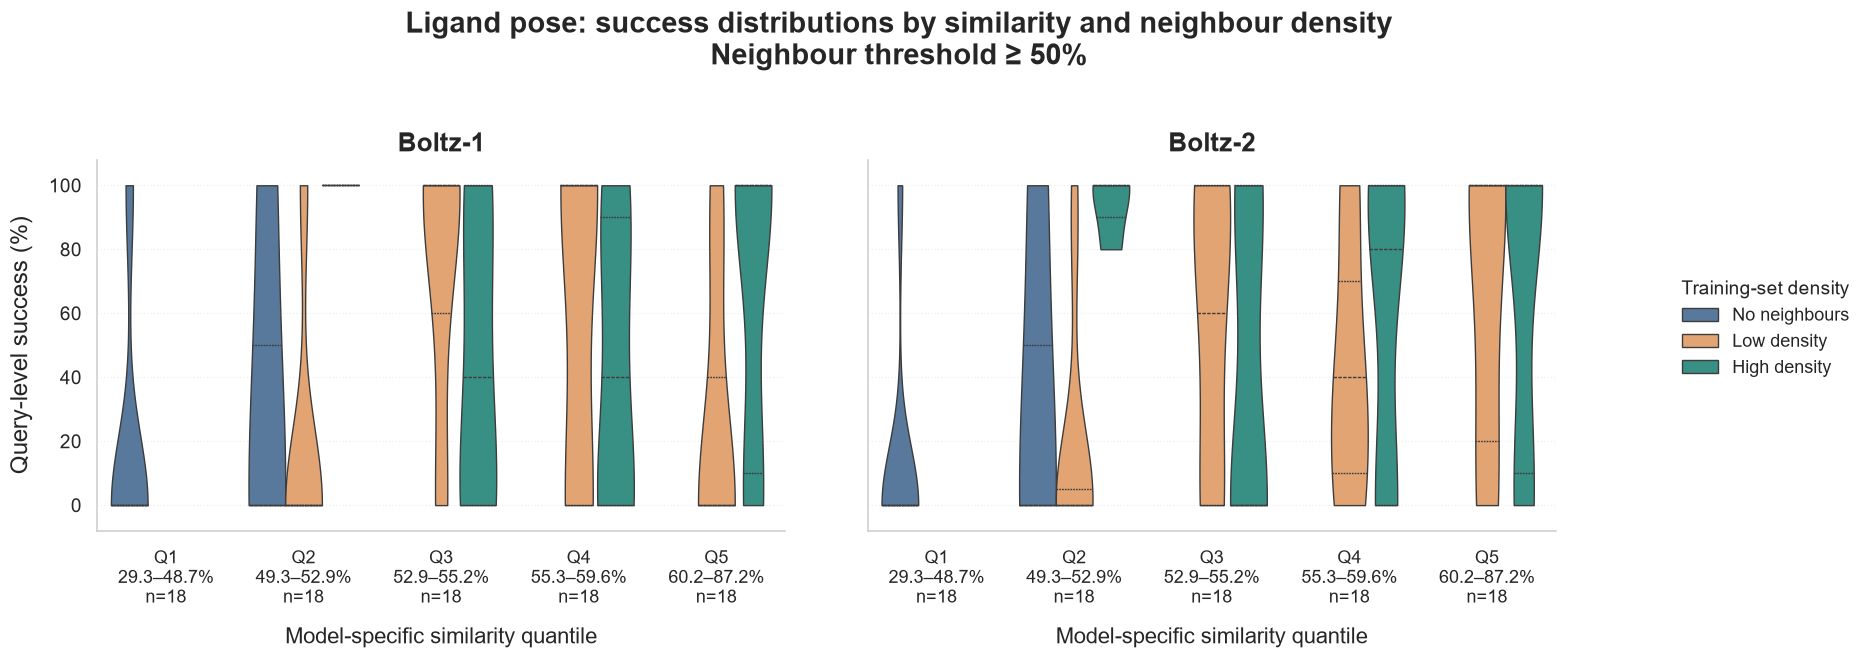

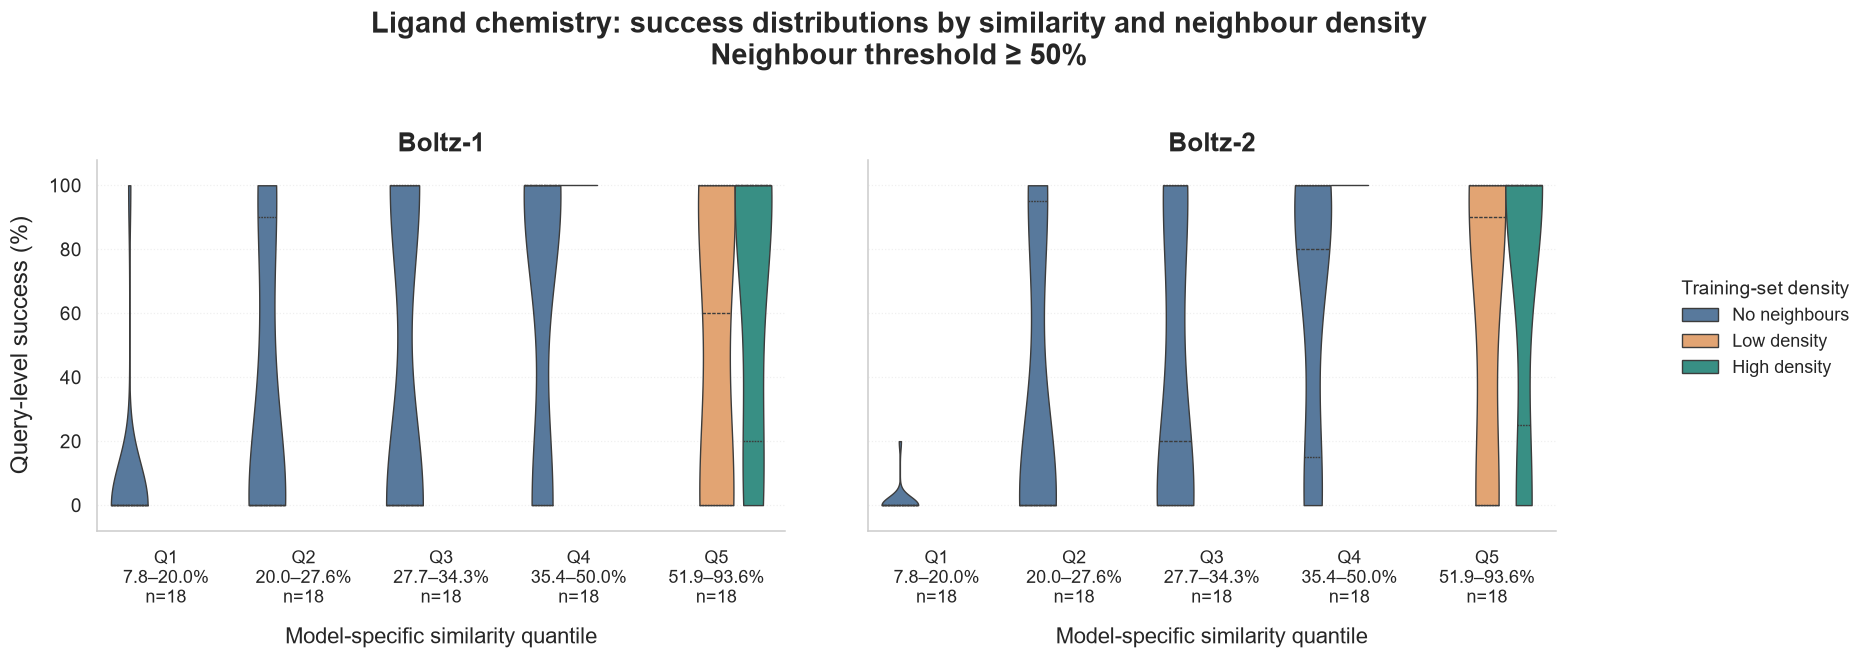

Line figures


,metric,png,pdf
0,Protein sequence,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
1,Protein structure,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
2,Pocket,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
3,Interaction,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
4,Ligand pose,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
5,Ligand chemistry,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...


Violin figures


,metric,png,pdf
0,Protein sequence,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
1,Protein structure,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
2,Pocket,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
3,Interaction,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
4,Ligand pose,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...
5,Ligand chemistry,C:\Users\emitr\OneDrive\Documentos\University ...,C:\Users\emitr\OneDrive\Documentos\University ...


In [11]:
DENSITY_ORDER = [
    "No neighbours",
    "Low density",
    "High density",
]

COLORS = {
    "No neighbours": "#4c78a8",
    "Low density": "#f4a261",
    "High density": "#2a9d8f",
}

QUANTILE_ORDER = [
    f"Q{i}"
    for i in range(1, N_QUANTILES + 1)
]

# Different positions reduce overlap between n labels.
LABEL_OFFSETS = {
    "No neighbours": (-10, 17),
    "Low density": (0, -21),
    "High density": (10, 17),
}


def bootstrap_density_curves(
    metric_queries,
    n_bootstrap=2000,
    random_seed=42,
):
    """
    Calculate mean success and pointwise query-bootstrap 95%
    confidence intervals for every model, quantile and density group.
    """

    random_generator = np.random.default_rng(
        random_seed
    )

    summary_rows = []

    grouped = (
        metric_queries
        .dropna(
            subset=[
                "model",
                "similarity_quantile",
                "density_group",
                "success_percent",
            ]
        )
        .groupby(
            [
                "model",
                "similarity_quantile",
                "density_group",
            ],
            observed=True,
        )
    )

    for (
        model,
        similarity_quantile,
        density_group,
    ), group_df in grouped:

        # Each complex is the independent statistical unit.
        success_values = (
            group_df
            .drop_duplicates("pdb_id")[
                "success_percent"
            ]
            .astype(float)
            .to_numpy()
        )

        n_queries = len(success_values)

        if n_queries == 0:
            continue

        bootstrap_means = np.empty(
            n_bootstrap,
            dtype=float,
        )

        for bootstrap_iteration in range(
            n_bootstrap
        ):
            bootstrap_sample = (
                random_generator.choice(
                    success_values,
                    size=n_queries,
                    replace=True,
                )
            )

            bootstrap_means[
                bootstrap_iteration
            ] = bootstrap_sample.mean()

        summary_rows.append({
            "model": model,
            "similarity_quantile": (
                similarity_quantile
            ),
            "density_group": density_group,
            "mean_success_percent": (
                success_values.mean()
            ),
            "n_queries": n_queries,
            "confidence_lower_95_percent": (
                np.quantile(
                    bootstrap_means,
                    0.025,
                )
            ),
            "confidence_upper_95_percent": (
                np.quantile(
                    bootstrap_means,
                    0.975,
                )
            ),
        })

    return pd.DataFrame(summary_rows)


def get_density_legend_label(
    model,
    metric_name,
    density_group,
):
    """
    Create labels such as:
    No neighbours (0)
    Low density (1–17)
    High density (18–3084)
    """

    required_columns = {
        "model",
        "metric",
        "density_group",
        "minimum_density",
        "maximum_density",
    }

    if not required_columns.issubset(
        density_definition_df.columns
    ):
        return density_group

    selected = density_definition_df.loc[
        density_definition_df["model"].eq(model)
        & density_definition_df["metric"].eq(
            metric_name
        )
        & density_definition_df[
            "density_group"
        ].eq(density_group)
    ]

    if selected.empty:
        return density_group

    selected = selected.iloc[0]

    minimum_density = int(
        selected["minimum_density"]
    )

    maximum_density = int(
        selected["maximum_density"]
    )

    if density_group == "No neighbours":
        return "No neighbours (0)"

    return (
        f"{density_group} "
        f"({minimum_density}–{maximum_density})"
    )


# ------------------------------------------------------------------
# Typography designed for figures occupying an A4 page
# ------------------------------------------------------------------

publication_style = {
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "DejaVu Sans",
        "Liberation Sans",
    ],
    "font.size": 15,
    "axes.titlesize": 19,
    "axes.titleweight": "semibold",
    "axes.labelsize": 17,
    "axes.labelweight": "normal",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "figure.titlesize": 21,
    "figure.titleweight": "semibold",
    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.dpi": 300,
}

line_figure_paths = []
violin_figure_paths = []


with plt.rc_context(publication_style):

    # ==============================================================
    # LINE PLOTS WITH BOOTSTRAP CONFIDENCE INTERVALS
    # ==============================================================

    for metric_name in METRICS.values():

        metric_queries = density_query_df.loc[
            density_query_df["metric"].eq(
                metric_name
            )
        ].copy()

        if metric_queries.empty:
            print(
                f"No data available for {metric_name}"
            )
            continue

        threshold = (
            metric_queries["threshold"].iloc[0]
        )

        safe_name = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            metric_name.lower(),
        ).strip("_")

        metric_curve_summary = (
            bootstrap_density_curves(
                metric_queries=metric_queries,
                n_bootstrap=2000,
                random_seed=42,
            )
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(18, 8.5),
            sharey=True,
        )

        for ax, model in zip(
            axes,
            ["Boltz-1", "Boltz-2"],
        ):

            model_queries = metric_queries.loc[
                metric_queries["model"].eq(
                    model
                )
            ].copy()

            model_curves = (
                metric_curve_summary.loc[
                    metric_curve_summary[
                        "model"
                    ].eq(model)
                ].copy()
            )

            # Model-specific similarity ranges represented by Q1–Q5.
            quantile_ranges = (
                model_queries
                .dropna(
                    subset=[
                        "similarity_quantile",
                        "visualisation_similarity",
                    ]
                )
                .groupby(
                    "similarity_quantile",
                    observed=True,
                )["visualisation_similarity"]
                .agg(["min", "max"])
            )

            quantile_tick_labels = []

            for quantile in QUANTILE_ORDER:

                if quantile in quantile_ranges.index:

                    minimum_similarity = (
                        quantile_ranges.loc[
                            quantile,
                            "min",
                        ]
                    )

                    maximum_similarity = (
                        quantile_ranges.loc[
                            quantile,
                            "max",
                        ]
                    )

                    quantile_tick_labels.append(
                        f"{quantile}\n"
                        f"{minimum_similarity:.1f}–"
                        f"{maximum_similarity:.1f}%"
                    )

                else:
                    quantile_tick_labels.append(
                        quantile
                    )

            for density_group in DENSITY_ORDER:

                group_df = model_curves.loc[
                    model_curves[
                        "density_group"
                    ].eq(density_group)
                ].copy()

                if group_df.empty:
                    continue

                group_df["quantile_index"] = (
                    group_df[
                        "similarity_quantile"
                    ]
                    .map({
                        quantile: index
                        for index, quantile
                        in enumerate(
                            QUANTILE_ORDER
                        )
                    })
                )

                group_df = (
                    group_df
                    .dropna(
                        subset=["quantile_index"]
                    )
                    .sort_values(
                        "quantile_index"
                    )
                )

                if group_df.empty:
                    continue

                x_values = (
                    group_df["quantile_index"]
                    .astype(float)
                    .to_numpy()
                )

                mean_values = (
                    group_df[
                        "mean_success_percent"
                    ]
                    .astype(float)
                    .to_numpy()
                )

                lower_values = (
                    group_df[
                        "confidence_lower_95_percent"
                    ]
                    .astype(float)
                    .to_numpy()
                )

                upper_values = (
                    group_df[
                        "confidence_upper_95_percent"
                    ]
                    .astype(float)
                    .to_numpy()
                )

                color = COLORS[density_group]

                # Pointwise bootstrap 95% confidence band.
                ax.fill_between(
                    x_values,
                    lower_values,
                    upper_values,
                    color=color,
                    alpha=0.16,
                    linewidth=0,
                    zorder=1,
                )

                density_label = (
                    get_density_legend_label(
                        model=model,
                        metric_name=metric_name,
                        density_group=density_group,
                    )
                )

                # Mean success curve.
                ax.plot(
                    x_values,
                    mean_values,
                    color=color,
                    marker="o",
                    markersize=8.5,
                    markeredgecolor="white",
                    markeredgewidth=0.8,
                    linewidth=2.6,
                    label=density_label,
                    zorder=3,
                )

                # Number of complexes contributing to every point.
                (
                    x_offset,
                    y_offset,
                ) = LABEL_OFFSETS[
                    density_group
                ]

                for row in group_df.itertuples(
                    index=False
                ):

                    ax.annotate(
                        f"n={int(row.n_queries)}",
                        xy=(
                            float(
                                row.quantile_index
                            ),
                            float(
                                row.mean_success_percent
                            ),
                        ),
                        xytext=(
                            x_offset,
                            y_offset,
                        ),
                        textcoords="offset points",
                        ha="center",
                        va="center",
                        fontsize=12,
                        fontweight="normal",
                        color=color,
                        bbox={
                            "boxstyle": (
                                "round,pad=0.18"
                            ),
                            "facecolor": "white",
                            "edgecolor": "none",
                            "alpha": 0.82,
                        },
                        zorder=4,
                    )

            ax.set_xticks(
                range(len(QUANTILE_ORDER)),
                labels=quantile_tick_labels,
            )

            ax.set_xlabel(
                f"{metric_name} quantile\n"
                f"Neighbour threshold ≥ "
                f"{threshold:g}%",
                fontsize=17,
                labelpad=14,
            )

            ax.set_title(
                model,
                fontsize=19,
                fontweight="semibold",
                y=1.22,
                pad=0,
            )

            ax.set_ylim(-5, 105)

            ax.tick_params(
                axis="x",
                labelsize=14,
                pad=8,
            )

            ax.tick_params(
                axis="y",
                labelsize=14,
                pad=6,
            )

            ax.grid(
                axis="y",
                linestyle=":",
                linewidth=0.9,
                alpha=0.32,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            legend = ax.legend(
                title="Training-set density",
                frameon=False,
                loc="lower center",
                bbox_to_anchor=(0.5, 1.015),
                ncol=3,
                borderaxespad=0,
                columnspacing=1.15,
                handlelength=1.8,
                handletextpad=0.45,
                labelspacing=0.4,
                fontsize=11.5,
            )

            legend.get_title().set_fontsize(12.5)
            legend.get_title().set_fontweight("normal")

            ax.text(
                0.01,
                0.015,
                (
                    "Shading indicates pointwise "
                    "query-bootstrap 95% CIs"
                ),
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=11.5,
                color="#555555",
            )

        axes[0].set_ylabel(
            "Mean prediction success (%)",
            fontsize=17,
            labelpad=12,
        )

        axes[1].set_ylabel("")

        fig.suptitle(
            f"{metric_name}: prediction success across "
            f"similarity\nand training-set density",
            fontsize=21,
            fontweight="semibold",
            y=0.985,
        )

        fig.subplots_adjust(
            left=0.085,
            right=0.98,
            bottom=0.21,
            top=0.70,
            wspace=0.10,
        )

        line_path = (
            OUTPUT_DIR
            / (
                f"{safe_name}_boltz1_boltz2_"
                "density_lines_bootstrap_ci.png"
            )
        )

        fig.savefig(
            line_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        pdf_path = (
            OUTPUT_DIR
            / (
                f"{safe_name}_boltz1_boltz2_"
                "density_lines_bootstrap_ci.pdf"
            )
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white",
        )

        plt.show()

        line_figure_paths.append({
            "metric": metric_name,
            "png": str(line_path),
            "pdf": str(pdf_path),
        })

    # ==============================================================
    # VIOLIN PLOTS STRATIFIED BY NEIGHBOUR DENSITY
    # ==============================================================

    for metric_name in METRICS.values():

        metric_queries = density_query_df.loc[
            density_query_df["metric"].eq(
                metric_name
            )
        ].copy()

        if metric_queries.empty:
            continue

        threshold = (
            metric_queries["threshold"].iloc[0]
        )

        safe_name = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            metric_name.lower(),
        ).strip("_")

        violin_data = metric_queries.dropna(
            subset=[
                "similarity_quantile",
                "success_percent",
            ]
        )

        if violin_data.empty:
            continue

        g = sns.catplot(
            data=violin_data,
            x="similarity_quantile",
            y="success_percent",
            order=QUANTILE_ORDER,
            hue="density_group",
            hue_order=DENSITY_ORDER,
            palette=COLORS,
            col="model",
            col_order=["Boltz-1", "Boltz-2"],
            kind="violin",
            inner="quartile",
            cut=0,
            density_norm="width",
            common_norm=False,
            height=7.0,
            aspect=1.25,
            linewidth=1.0,
            legend=True,
        )

        g.set(
            ylim=(-8, 108)
        )

        g.set_titles(
            "{col_name}",
            size=19,
            weight="semibold",
        )

        for model, ax in g.axes_dict.items():

            model_queries = violin_data.loc[
                violin_data["model"].eq(
                    model
                )
            ]

            # Total unique complexes represented in each quantile.
            total_counts = (
                model_queries
                .groupby(
                    "similarity_quantile",
                    observed=True,
                )["pdb_id"]
                .nunique()
            )

            # Quantile-specific percentage ranges.
            quantile_ranges = (
                model_queries
                .dropna(
                    subset=[
                        "similarity_quantile",
                        "visualisation_similarity",
                    ]
                )
                .groupby(
                    "similarity_quantile",
                    observed=True,
                )["visualisation_similarity"]
                .agg(["min", "max"])
            )

            tick_labels = []

            for quantile in QUANTILE_ORDER:

                total_n = int(
                    total_counts.get(
                        quantile,
                        0,
                    )
                )

                if quantile in quantile_ranges.index:

                    minimum_similarity = (
                        quantile_ranges.loc[
                            quantile,
                            "min",
                        ]
                    )

                    maximum_similarity = (
                        quantile_ranges.loc[
                            quantile,
                            "max",
                        ]
                    )

                    tick_labels.append(
                        f"{quantile}\n"
                        f"{minimum_similarity:.1f}–"
                        f"{maximum_similarity:.1f}%\n"
                        f"n={total_n}"
                    )

                else:
                    tick_labels.append(
                        f"{quantile}\n"
                        f"n={total_n}"
                    )

            ax.set_xticks(
                range(len(QUANTILE_ORDER)),
                labels=tick_labels,
            )

            ax.tick_params(
                axis="x",
                labelsize=13,
                pad=8,
            )

            ax.tick_params(
                axis="y",
                labelsize=14,
                pad=6,
            )

            ax.set_xlabel(
                "Model-specific similarity quantile",
                fontsize=16,
                labelpad=14,
            )

            ax.grid(
                axis="y",
                linestyle=":",
                linewidth=0.9,
                alpha=0.30,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        g.axes.flat[0].set_ylabel(
            "Query-level success (%)",
            fontsize=17,
            labelpad=12,
        )

        if len(g.axes.flat) > 1:
            g.axes.flat[1].set_ylabel("")

        # Improve the automatically generated Seaborn legend.
        if g._legend is not None:

            g._legend.set_title(
                "Training-set density"
            )

            g._legend.get_title().set_fontsize(
                14
            )

            g._legend.get_title().set_fontweight(
                "normal"
            )

            for legend_text in (
                g._legend.get_texts()
            ):
                legend_text.set_fontsize(13)

            g._legend.set_frame_on(False)

        g.figure.subplots_adjust(
            left=0.085,
            right=0.84,
            top=0.77,
            bottom=0.24,
            wspace=0.12,
        )

        g.figure.suptitle(
            f"{metric_name}: success distributions by "
            f"similarity and neighbour density\n"
            f"Neighbour threshold ≥ {threshold:g}%",
            fontsize=21,
            fontweight="semibold",
            y=0.985,
        )

        violin_path = (
            OUTPUT_DIR
            / (
                f"{safe_name}_density_"
                "violins_with_counts.png"
            )
        )

        violin_pdf_path = (
            OUTPUT_DIR
            / (
                f"{safe_name}_density_"
                "violins_with_counts.pdf"
            )
        )

        g.figure.savefig(
            violin_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        g.figure.savefig(
            violin_pdf_path,
            bbox_inches="tight",
            facecolor="white",
        )

        plt.show()

        violin_figure_paths.append({
            "metric": metric_name,
            "png": str(violin_path),
            "pdf": str(violin_pdf_path),
        })


print("Line figures")
display(
    pd.DataFrame(line_figure_paths)
)

print("Violin figures")
display(
    pd.DataFrame(violin_figure_paths)
)

## Save auditable numerical outputs

The query-level table records success, maximum similarity, mean above-threshold similarity, neighbour count, density class and model-specific quantile. It is the main numerical source for the figures.


In [9]:
coverage_df.to_csv(OUTPUT_DIR / "input_coverage.csv", index=False)
threshold_table.to_csv(OUTPUT_DIR / "fixed_similarity_thresholds.csv", index=False)
density_definition_df.to_csv(OUTPUT_DIR / "density_group_definitions.csv", index=False)
quantile_boundaries_df.to_csv(OUTPUT_DIR / "model_specific_quantile_boundaries.csv", index=False)
curve_summary_df.to_csv(OUTPUT_DIR / "success_similarity_density_curves.csv", index=False)
density_query_df.to_csv(OUTPUT_DIR / "query_level_success_similarity_density.csv", index=False)
density_query_df.to_parquet(
    OUTPUT_DIR / "query_level_success_similarity_density.parquet", index=False
)

status_df = pd.DataFrame({"pdb_id": ALL_PDB_IDS})
status_df["similarity_status"] = np.select(
    [
        status_df["pdb_id"].isin(NOT_CALCULABLE),
        status_df["pdb_id"].isin(NO_TARGETS),
    ],
    ["not_calculable", "no_targets"],
    default="calculated",
)
status_df.to_csv(OUTPUT_DIR / "all_100_similarity_status.csv", index=False)

print("Saved all tables and figures to:", OUTPUT_DIR)


Saved all tables and figures to: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\boltz_success_similarity_density
